Project Introduction

In [18]:
"""
=========================================================
Financial Sales Analysis Project
=========================================================

Objective:
Perform data cleaning, data validation, feature engineering,
exploratory data analysis, KPI analysis, and create a clean
dataset for dashboard visualization.

Author: Vibha Rana
Tools Used:
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
=========================================================
"""

'\n=========================================================\nFinancial Sales Analysis Project\n=========================================================\n\nObjective:\nPerform data cleaning, data validation, feature engineering,\nexploratory data analysis, KPI analysis, and create a clean\ndataset for dashboard visualization.\n\nAuthor: Vibha Rana\nTools Used:\n- Python\n- Pandas\n- NumPy\n- Matplotlib\n- Seaborn\n=========================================================\n'

Import Libraries

In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

Load Dataset

In [20]:
df = pd.read_csv("advanced_financial_messy_dataset.csv")

df.head()

,Transaction_ID,Date,Customer_ID,Customer_Age,Gender,Region,Product_Category,Units_Sold,Marketing_Spend,Revenue,Discount_Percent,Customer_Satisfaction,Profit
0,TXN10000,2023-06-25,1352,47.0,Other,South,Retail,14,6007.0,37876,11,8.0,27702.64
1,TXN10001,2024-06-21,1437,28.0,Male,West,Retail,7,3695.0,27896,36,2.0,14158.44
2,TXN10002,2024-05-17,1487,27.0,Female,West,Electronics,13,6631.0,41339,5,4.0,32641.05
3,TXN10003,2023-07-31,1118,49.0,male,West,Retail,12,9704.0,31008,22,3.0,14482.24
4,TXN10004,2025-07-08,1461,56.0,NaN,East,Retail,6,850.0,9737,1,1.0,8789.63


Initial Data Exploration

In [21]:
print("Dataset Shape")
display(df.shape)

print("Column Names")
display(df.columns)

print("Dataset Information")
df.info()

print("Statistical Summary")
display(df.describe())

print("Missing Values")
display(df.isnull().sum())

Dataset Shape


(1280, 13)

Column Names


Index(['Transaction_ID', 'Date', 'Customer_ID', 'Customer_Age', 'Gender',
       'Region', 'Product_Category', 'Units_Sold', 'Marketing_Spend',
       'Revenue', 'Discount_Percent', 'Customer_Satisfaction', 'Profit'],
      dtype='object')

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1280 entries, 0 to 1279
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Transaction_ID         1280 non-null   object 
 1   Date                   1280 non-null   object 
 2   Customer_ID            1280 non-null   int64  
 3   Customer_Age           1202 non-null   float64
 4   Gender                 1207 non-null   object 
 5   Region                 1203 non-null   object 
 6   Product_Category       1280 non-null   object 
 7   Units_Sold             1280 non-null   int64  
 8   Marketing_Spend        1203 non-null   float64
 9   Revenue                1280 non-null   int64  
 10  Discount_Percent       1280 non-null   int64  
 11  Customer_Satisfaction  1204 non-null   float64
 12  Profit                 1280 non-null   float64
dtypes: float64(4), int64(4), object(5)
memory usage: 130.1+ KB
Statistical Summary


,Customer_ID,Customer_Age,Units_Sold,Marketing_Spend,Revenue,Discount_Percent,Customer_Satisfaction,Profit
count,1280.000000,1202.000000,1280.000000,1203.000000,1280.000000,1280.000000,1204.000000,1280.000000
mean,1247.497656,43.181364,9.989844,4969.244389,25489.271875,19.664062,5.432724,15529.503758
std,144.166646,15.227677,5.485988,2844.988585,14457.652490,11.480192,2.887119,12322.399510
min,1001.000000,18.000000,1.000000,104.000000,500.000000,0.000000,1.000000,-9358.480000
25%,1117.750000,30.000000,5.000000,2522.000000,13111.000000,10.000000,3.000000,5613.025000
50%,1257.500000,42.000000,10.000000,4825.000000,25782.500000,19.000000,5.000000,15279.460000
75%,1367.000000,57.000000,15.000000,7508.500000,37836.000000,30.000000,8.000000,25320.590000
max,1499.000000,69.000000,19.000000,9999.000000,49955.000000,39.000000,10.000000,45728.550000


Missing Values


Transaction_ID            0
Date                      0
Customer_ID               0
Customer_Age             78
Gender                   73
Region                   77
Product_Category          0
Units_Sold                0
Marketing_Spend          77
Revenue                   0
Discount_Percent          0
Customer_Satisfaction    76
Profit                    0
dtype: int64

Data Quality Assessment

In [22]:
# missing value

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing.sort_values(
    by="Percentage",
    ascending=False
)

,Missing Values,Percentage
Customer_Age,78,6.093750
Marketing_Spend,77,6.015625
Region,77,6.015625
Customer_Satisfaction,76,5.937500
Gender,73,5.703125
Date,0,0.000000
Customer_ID,0,0.000000
Transaction_ID,0,0.000000
Product_Category,0,0.000000
Units_Sold,0,0.000000


In [23]:
# Duplicate Records

duplicates = df.duplicated().sum()

print(f"Duplicate Records : {duplicates}")

Duplicate Records : 68


In [24]:
# Data Types

df.dtypes

Transaction_ID            object
Date                      object
Customer_ID                int64
Customer_Age             float64
Gender                    object
Region                    object
Product_Category          object
Units_Sold                 int64
Marketing_Spend          float64
Revenue                    int64
Discount_Percent           int64
Customer_Satisfaction    float64
Profit                   float64
dtype: object

In [25]:
# Invalid Values

(df['Revenue'] < 0).sum()

(df['Units_Sold'] < 0).sum()


np.int64(0)

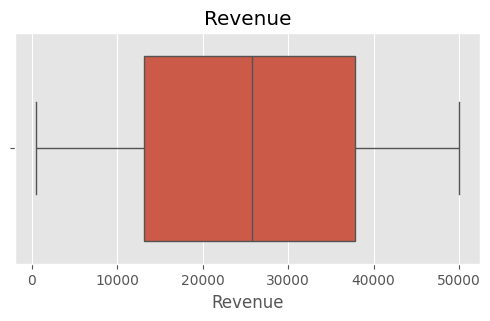

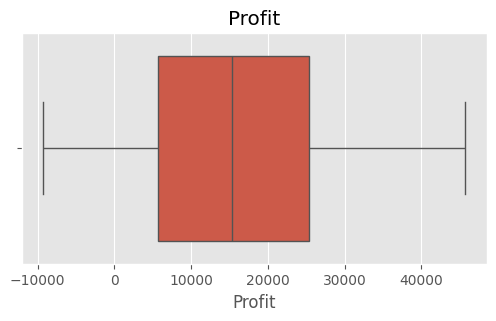

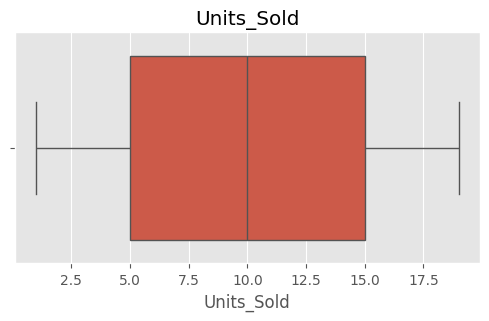

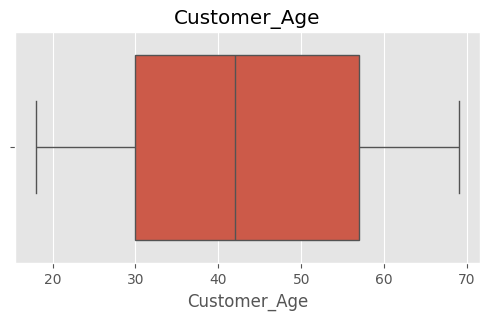

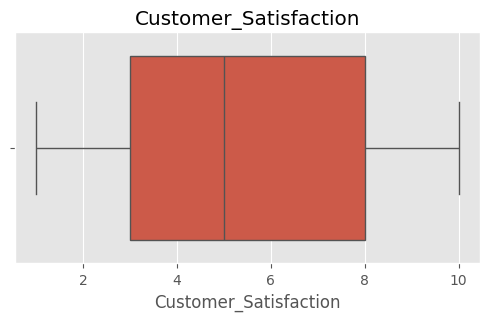

In [26]:
# Outlier Detection

numerical = [
    'Revenue',
    'Profit',
    'Units_Sold',
    'Customer_Age',
    'Customer_Satisfaction'
]

for col in numerical:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Data Cleaning

In [27]:
# Remove Duplicates

df.drop_duplicates(inplace=True)

In [28]:
# Convert Date

df['Date'] = pd.to_datetime(df['Date'])

In [29]:
# Handle Missing Values

df['Customer_Age'].fillna(
    df['Customer_Age'].median(),
    inplace=True
)

df['Gender'].fillna(
    df['Gender'].mode()[0],
    inplace=True
)

df['Region'].fillna(
    df['Region'].mode()[0],
    inplace=True
)

df['Marketing_Spend'].fillna(
    df['Marketing_Spend'].median(),
    inplace=True
)

df['Customer_Satisfaction'].fillna(
    df['Customer_Satisfaction'].median(),
    inplace=True
)


In [32]:
# Standardize Text Columns

text_cols = [
    'Region',
    'Product_Category',
    'Gender'
]

for col in text_cols:
    df[col] = (
        df[col]
        .str.strip()
        .str.title()
    )

Feature Engineering

In [34]:
# month

df['Month'] = df['Date'].dt.month_name()

In [35]:
# Quarter

df['Quarter'] = df['Date'].dt.quarter

In [36]:
# Year

df['Year'] = df['Date'].dt.year

In [37]:
# Profit Margin

df['Profit_Margin'] = (
    df['Profit'] /
    df['Revenue']
)*100


In [38]:
# Age Groups

bins=[18,25,35,45,55,100]

labels=[
'18-25',
'26-35',
'36-45',
'46-55',
'56+'
]

df['Age_Group']=pd.cut(
df['Customer_Age'],
bins=bins,
labels=labels
)

Exploratory Data Analysis

<Axes: xlabel='Month'>

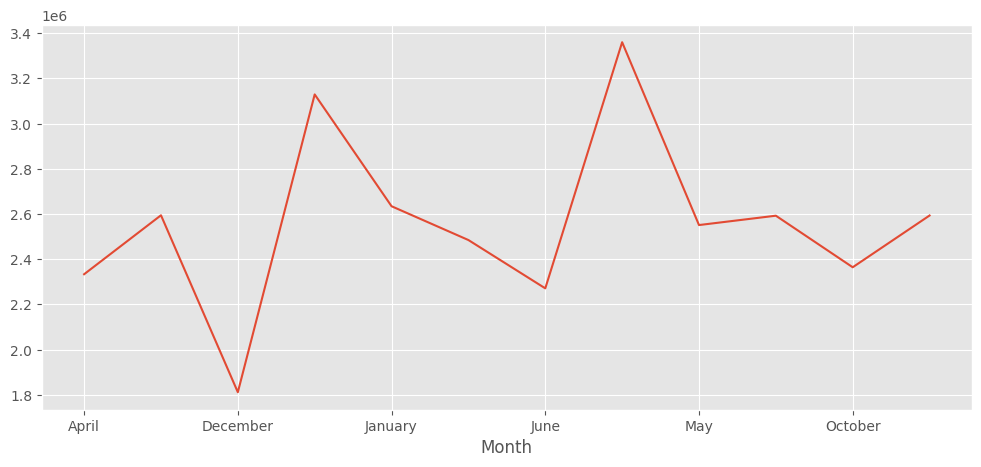

In [39]:
# Revenue Trend

monthly=df.groupby("Month")["Revenue"].sum()

monthly.plot(figsize=(12,5))

<Axes: ylabel='Region'>

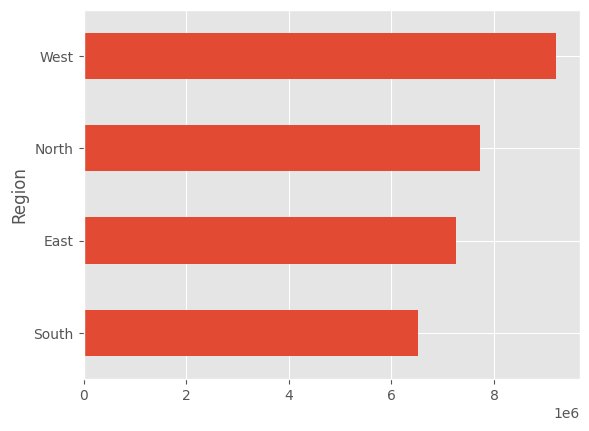

In [40]:
# Revenue by Region

df.groupby("Region")["Revenue"].sum().sort_values().plot.barh()

<Axes: xlabel='Product_Category'>

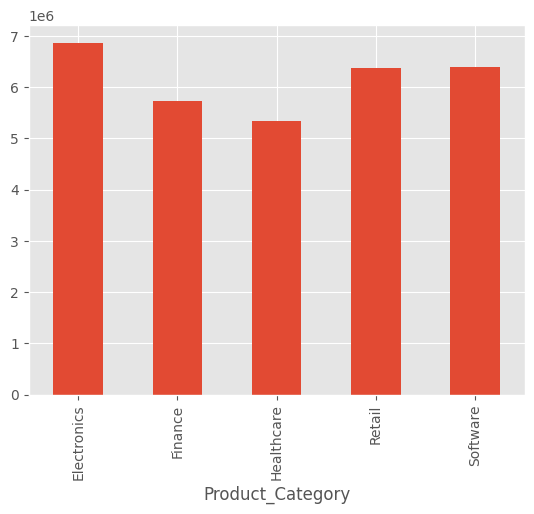

In [41]:
# Revenue by Category

df.groupby("Product_Category")["Revenue"].sum().plot.bar()

<Axes: xlabel='Customer_Satisfaction', ylabel='Count'>

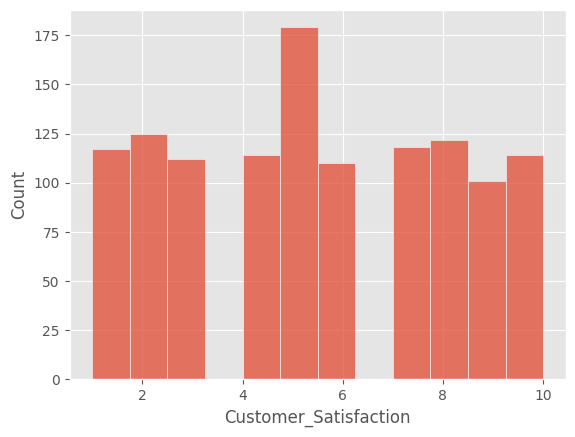

In [42]:
# Customer Satisfaction

sns.histplot(df["Customer_Satisfaction"])

KPI Analysis

In [43]:
total_revenue = df['Revenue'].sum()

total_profit = df['Profit'].sum()

profit_margin = (
    total_profit /
    total_revenue
)*100

transactions = len(df)

avg_satisfaction = df[
'Customer_Satisfaction'
].mean()

In [44]:
print(f"Revenue : ${total_revenue:,.2f}")
print(f"Profit : ${total_profit:,.2f}")
print(f"Margin : {profit_margin:.2f}%")
print(f"Transactions : {transactions}")
print(f"Satisfaction : {avg_satisfaction:.2f}")

Revenue : $30,722,027.00
Profit : $18,727,537.12
Margin : 60.96%
Transactions : 1212
Satisfaction : 5.42


KPI & BUSINESS METRICS

In [49]:

# Top Revenue Region
top_region = df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)
print("\nTop Revenue by Region")
print(top_region)

# Top Product Category
top_category = df.groupby('Product_Category')['Revenue'].sum().sort_values(ascending=False)
print("\nTop Revenue by Product Category")
print(top_category)

# Best Performing Month
best_month = df.groupby('Month')['Revenue'].sum().sort_values(ascending=False)
print("\nRevenue by Month")
print(best_month)

# Highest Profit Category
profit_category = df.groupby('Product_Category')['Profit'].sum().sort_values(ascending=False)
print("\nProfit by Product Category")
print(profit_category)

# Revenue by Age Group
age_group = df.groupby('Age_Group')['Revenue'].sum().sort_values(ascending=False)
print("\nRevenue by Age Group")
print(age_group)

# Gender Distribution
gender = df['Gender'].value_counts()
print("\nCustomer Gender Distribution")
print(gender)

# Customer Satisfaction
print("\nCustomer Satisfaction Statistics")
print(df['Customer_Satisfaction'].describe())


Top Revenue by Region
Region
West     9204685
North    7732662
East     7262368
South    6522312
Name: Revenue, dtype: int64

Top Revenue by Product Category
Product_Category
Electronics    6870818
Software       6403338
Retail         6371786
Finance        5731194
Healthcare     5344891
Name: Revenue, dtype: int64

Revenue by Month
Month
March        3360092
February     3129132
January      2634500
August       2594579
September    2593551
November     2592666
May          2551260
July         2484960
October      2364561
April        2333730
June         2271250
December     1811746
Name: Revenue, dtype: int64

Profit by Product Category
Product_Category
Electronics    4202960.39
Retail         3978124.54
Software       3891122.47
Finance        3445880.64
Healthcare     3209449.08
Name: Profit, dtype: float64

Revenue by Age Group
Age_Group
56+      8431470
36-45    7579201
26-35    5515254
18-25    4350280
46-55    4336809
Name: Revenue, dtype: int64

Customer Gender Distributio

Export Clean Dataset

In [51]:
df.to_csv(
"financial_cleaned_dataset.csv",
index=False
)

Conclusion

In [50]:
print("""
Data Cleaning Completed Successfully.

✔ Missing Values Handled
✔ Duplicate Records Removed
✔ Data Types Validated
✔ Feature Engineering Completed
✔ KPIs Generated
✔ Dataset Ready for Dashboard
""")


Data Cleaning Completed Successfully.

✔ Missing Values Handled
✔ Duplicate Records Removed
✔ Data Types Validated
✔ Feature Engineering Completed
✔ KPIs Generated
✔ Dataset Ready for Dashboard

